# AD CLICK PREDICTION
---
**DATA SCIENCE PROJECT**

---

### PROBLEM STATEMENT

Digital advertisers face a major challenge in identifying which users are likely to click on ads, since engagement depends on various factors like time spent on site, age, area income, internet usage, and the time of day.

This project builds a **Machine Learning model** to predict whether a user will **Click on an Ad (Clicked on Ad = 1)** or **Not Click (Clicked on Ad = 0)** based on user behavioral and demographic features.

---

### OBJECTIVES
- To perform thorough Exploratory Data Analysis on the Ad Click dataset
- To engineer meaningful new features for improved model performance
- To predict whether a user will click on an ad

---

### DATASET SUMMARY

- **Source:** Advertisement Click on Ad Dataset (Kaggle)
- **Rows:** 1,000
- **Columns:** 10
- **Target Variable:** `Clicked on Ad` (1 = Clicked, 0 = Not Clicked)

---

### Feature Description

| Feature | Type | Description |
|---|---|---|
| `Daily Time Spent on Site` | Numeric | Time (in minutes) the user spends on the site per day |
| `Age` | Numeric | Age of the user in years |
| `Area Income` | Numeric | Average income of the user's geographical area |
| `Daily Internet Usage` | Numeric | Daily internet usage of the user in minutes |
| `Ad Topic Line` | Categorical | Headline/topic of the advertisement |
| `City` | Categorical | City where the user is located |
| `Male` | Binary | Gender of the user: 1 = Male, 0 = Female |
| `Country` | Categorical | Country where the user is located |
| `Timestamp` | DateTime | Date and time when the user saw the ad |
| `Clicked on Ad` | Binary | **Target Variable.** 1 = Clicked, 0 = Not Clicked |

---

### EDA (Exploratory Data Analysis)

In the Model Training Step, we first understand the dataset, identify problems such as missing values, duplicates, and outliers, then handle them using appropriate techniques before performing in-depth analysis.

---

## Importing Important Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy import stats
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')


- **Pandas** is required for reading, modifying, and analyzing the data.
- **Numpy** is necessary for efficient and faster mathematical calculations.
- **Matplotlib (Pyplot)** helps to create basic graphs and charts.
- **Seaborn** is the advanced visualization library which helps in statistical data visualization.
- **Scikit-learn** provides ML preprocessing tools such as encoding, scaling, and PCA.
- **Scipy** provides statistical tests including normality (skewness) analysis.
- **Collections / re** are used for keyword extraction in Ad Topic Line analysis.

---

## Loading Dataset

In [74]:
df = pd.read_csv('advertising (1).csv')

The dataset is loaded from a CSV file using pandas `read_csv()` function.

CSV (Comma Separated Values) is a raw tabular data format; `read_csv()` automatically converts it into a structured DataFrame assigned to `df`.

---

In [75]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 1000
Columns: 10


Our dataset has **1,000 rows** (user records) and **10 columns** (features).

---

In [76]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [77]:
df.tail()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0
999,45.01,26,29875.80,178.35,Virtual 5thgeneration emulation,Ronniemouth,0,Brazil,2016-06-03 21:43:21,1


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


From `df.info()`, we can observe:
- `Daily Time Spent on Site`, `Age`, `Area Income`, `Daily Internet Usage`, and `Male` are numeric features.
- `Ad Topic Line`, `City`, `Country` are text/categorical features.
- `Timestamp` is a datetime string that needs to be parsed.
- `Clicked on Ad` is the binary target variable.
- No missing values are present in this dataset.

---

## Step 1: Missing Data Checking and Handling

**Purpose:** Missing values can cause errors in model training and introduce bias. We first identify them, then handle using appropriate strategies.

---

In [79]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Missing value percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))


Missing values per column:
Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

Missing value percentage:
Daily Time Spent on Site    0.0
Age                         0.0
Area Income                 0.0
Daily Internet Usage        0.0
Ad Topic Line               0.0
City                        0.0
Male                        0.0
Country                     0.0
Timestamp                   0.0
Clicked on Ad               0.0
dtype: float64


**Observation:** This dataset has **no missing values** in any column. All 1,000 rows are complete. No imputation is required.

This is an ideal clean dataset to work with — we can proceed directly to duplicate checking.

---

## Step 2: Duplicate Data Checking and Handling

**Purpose:** Duplicate rows cause the model to overfit by learning repeated patterns. They must be identified and removed.

---

In [80]:
print("Total duplicate rows:", df.duplicated().sum())


Total duplicate rows: 0


**Observation:** No duplicate rows are found in this dataset. Every row is a unique user record.

---

In [81]:
# Unique value checking for categorical columns
print("Unique value counts per categorical column:")
for col in ['Ad Topic Line', 'City', 'Country']:
    print(f"  {col}: {df[col].nunique()} unique values")
print()
print("Male unique values:", df['Male'].unique())
print("Clicked on Ad unique values:", df['Clicked on Ad'].unique())


Unique value counts per categorical column:
  Ad Topic Line: 1000 unique values
  City: 969 unique values
  Country: 237 unique values

Male unique values: [0 1]
Clicked on Ad unique values: [0 1]


**Observation:**
- `Ad Topic Line` has 1,000 unique values — each ad has a different topic headline.
- `City` has many unique values — users are spread across diverse cities.
- `Country` has 237 unique countries — a truly global dataset.
- `Male` is binary (0 = Female, 1 = Male) — no unexpected entries.
- `Clicked on Ad` is binary (0 = Not Clicked, 1 = Clicked) — perfectly balanced (500 each).

No entity replacement is needed as all categorical values are consistent.

---

## Step 3: Encoding Approach (Categorical Features Only)

**Purpose:** Machine learning models work with numbers, not text. Categorical columns must be encoded into numeric form.

The categorical features in this dataset are: `Ad Topic Line`, `City`, and `Country`.

**Note:** `Male` is already binary (0/1) and `Clicked on Ad` is the target — neither needs encoding.

We use **Label Encoding** for `City` and `Country` because:
- They have a large number of unique values (many cities, 237 countries)
- One-Hot Encoding would create hundreds of columns, causing dimensionality explosion
- Label Encoding keeps the feature in a single column

`Ad Topic Line` is kept for keyword extraction in the Assigned EDA section and then dropped before modeling (since each value is unique).

---

In [82]:
# Store original text columns before encoding (needed for assigned EDA)
df_original = df.copy()

# Label Encoding for City and Country
le = LabelEncoder()

df['City_encoded'] = le.fit_transform(df['City'])
df['Country_encoded'] = le.fit_transform(df['Country'])

print("Label Encoding applied to City and Country!")
print(f"Shape: {df.shape}")
df[['City', 'City_encoded', 'Country', 'Country_encoded']].head()


Label Encoding applied to City and Country!
Shape: (1000, 12)


,City,City_encoded,Country,Country_encoded
0,Wrightburgh,961,Tunisia,215
1,West Jodi,903,Nauru,147
2,Davidton,111,San Marino,184
3,West Terrifurt,939,Italy,103
4,South Manuel,805,Iceland,96


Label Encoding assigns a unique integer to each unique string category. For example:
- Each city name → unique integer code
- Each country name → unique integer code

`Ad Topic Line` will be handled separately via keyword extraction in the Assigned EDA step.

---

## Step 4: Basic EDA

### a) Statistical Summary (describe)

The `describe()` function provides a statistical overview of all numeric features. This serves as a **baseline for comparison** before and after outlier handling.

---

In [83]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,City_encoded,Country_encoded
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000,486.323000,115.41000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025,279.311571,69.94372
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000,246.750000,54.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000,484.500000,113.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000,727.250000,177.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000,968.000000,236.00000


**Key observations from describe():**
- `Daily Time Spent on Site`: ranges from 32.6 to 91.4 minutes (mean ~65 min).
- `Age`: ranges from 19 to 61 years (mean ~36 years).
- `Area Income`: ranges from ~13,996 to ~79,485 (mean ~55,000) — possible lower outliers.
- `Daily Internet Usage`: ranges from 104.78 to 269.96 minutes (mean ~180 min).
- `Male`: ~48% of users are Male (binary column).
- `Clicked on Ad`: perfectly balanced — exactly 50% clicked.

---

### b) Graph Plotting for Numeric Features

---

KeyboardInterrupt: 

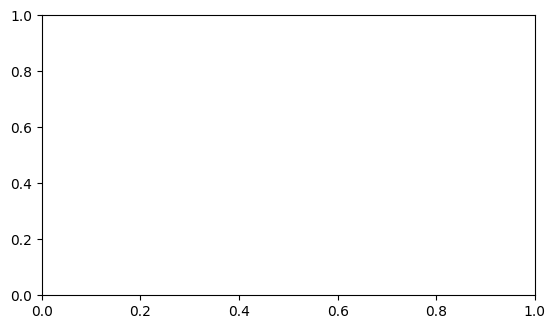

In [84]:
numeric_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for ax, col, color in zip(axes.flatten(), numeric_cols, colors):
    sns.histplot(df[col], bins=25, kde=True, ax=ax, color=color)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()


**Observations from numeric distributions:**
- `Daily Time Spent on Site`: approximately normally distributed, centered around 65 minutes.
- `Age`: roughly bell-shaped with slight right skew; most users are 25–45 years old.
- `Area Income`: left-skewed — most users have moderate-to-high income, with a tail of lower-income areas.
- `Daily Internet Usage`: bimodal distribution — two distinct usage clusters visible.

---

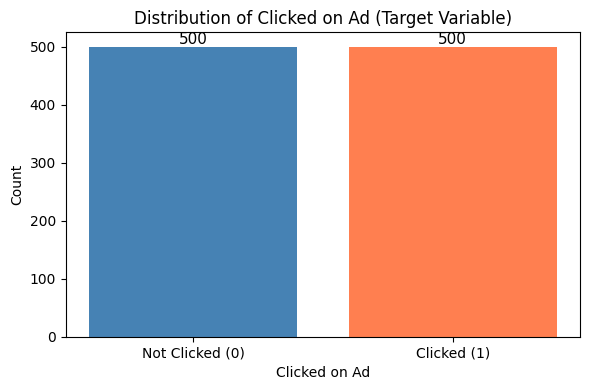

In [ ]:
# Target variable distribution
plt.figure(figsize=(6, 4))
click_counts = df['Clicked on Ad'].value_counts()
bars = plt.bar(['Not Clicked (0)', 'Clicked (1)'], click_counts.values, color=['steelblue', 'coral'])
plt.title('Distribution of Clicked on Ad (Target Variable)')
plt.xlabel('Clicked on Ad')
plt.ylabel('Count')
for bar, val in zip(bars, click_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


The target variable is **perfectly balanced** — exactly 500 clicks and 500 non-clicks. This means no class imbalance handling is needed during model training.

---

### c) Graph Plotting for Categorical Features

---

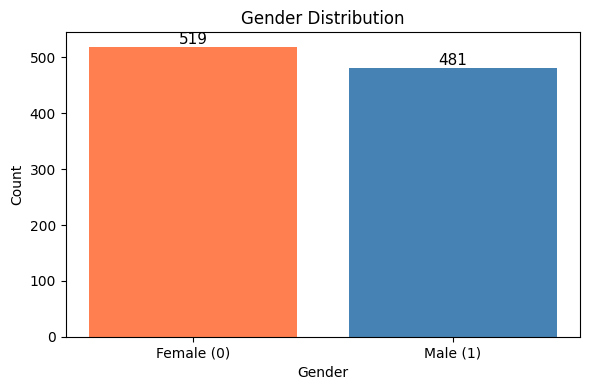

In [ ]:
# Gender distribution
plt.figure(figsize=(6, 4))
gender_counts = df['Male'].value_counts()
plt.bar(['Female (0)', 'Male (1)'], gender_counts.values, color=['coral', 'steelblue'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
for i, val in enumerate(gender_counts.values):
    plt.text(i, val + 5, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()


The dataset is nearly balanced by gender — 519 Female users and 481 Male users.

---

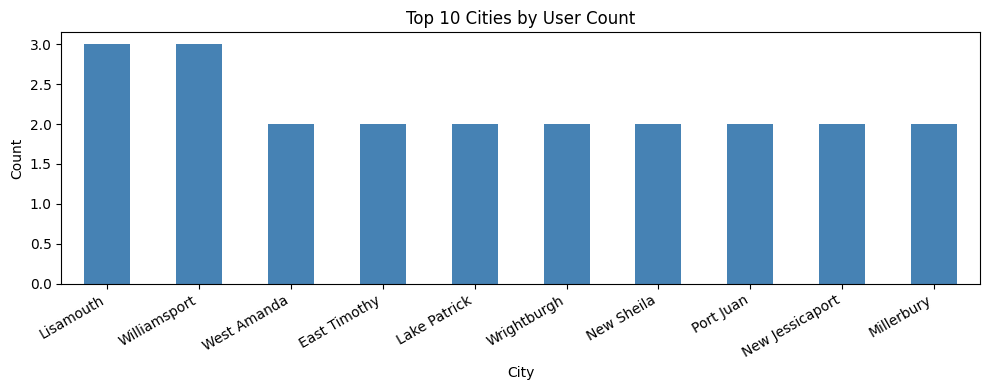

In [ ]:
# Top 10 cities by user count
top_cities = df_original['City'].value_counts().head(10)
plt.figure(figsize=(10, 4))
top_cities.plot(kind='bar', color='steelblue')
plt.title('Top 10 Cities by User Count')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


Most cities appear only 1–3 times in the dataset, confirming a highly diverse geographic spread.

---

## Step 5: Outlier Handling (Numeric Features Only)

**Purpose:** Outliers can distort model training and statistical computations. We visualize outliers using individual boxplots, compare multiple handling approaches, then apply the best one.

### i) Boxplot Visualization of Individual Numeric Features

---

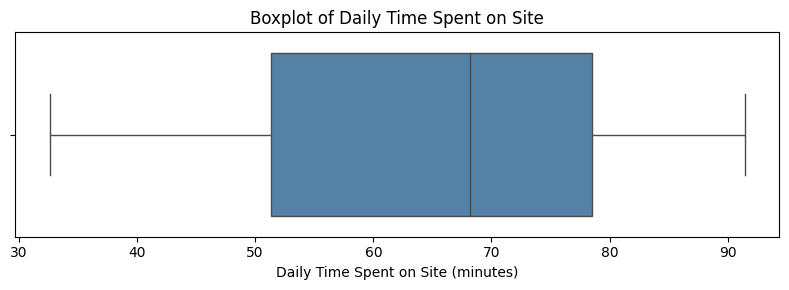

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Daily Time Spent on Site'], color='steelblue')
plt.title('Boxplot of Daily Time Spent on Site')
plt.xlabel('Daily Time Spent on Site (minutes)')
plt.tight_layout()
plt.show()


Daily Time Spent on Site shows a clean, symmetric distribution. No significant outliers are present.

---

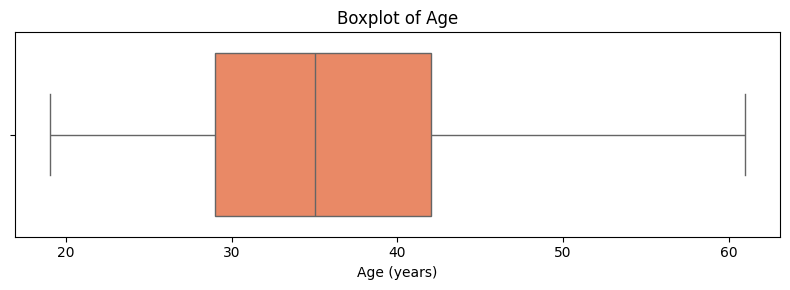

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Age'], color='coral')
plt.title('Boxplot of Age')
plt.xlabel('Age (years)')
plt.tight_layout()
plt.show()


Age is well distributed between 19 and 61 with no extreme outliers. The IQR range is clean.

---

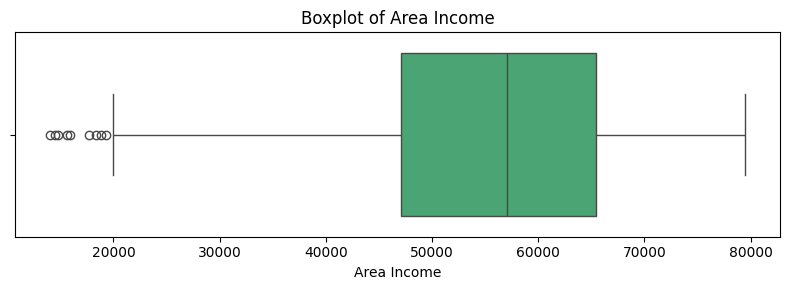

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Area Income'], color='mediumseagreen')
plt.title('Boxplot of Area Income')
plt.xlabel('Area Income')
plt.tight_layout()
plt.show()


Area Income has some lower-end outliers visible on the left side. These represent users from low-income geographic areas.

---

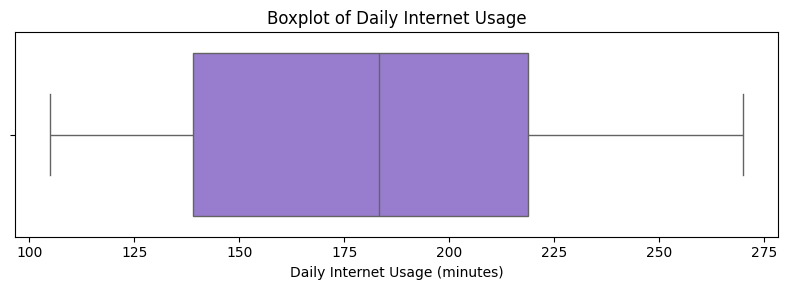

In [ ]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['Daily Internet Usage'], color='mediumpurple')
plt.title('Boxplot of Daily Internet Usage')
plt.xlabel('Daily Internet Usage (minutes)')
plt.tight_layout()
plt.show()


Daily Internet Usage shows a bimodal pattern with no extreme outliers beyond the IQR whiskers.

---

### ii) Evaluating Multiple Outlier Handling Approaches

We compare three common approaches on the feature with the most notable outliers (`Area Income`):

1. **IQR Capping (Winsorization):** Caps values at IQR boundaries — preserves all rows
2. **Z-score Removal:** Removes rows where |z| > 3 — may lose data
3. **Percentile Capping (1%–99%):** Caps at extreme percentiles — moderate approach

---

In [ ]:
col = 'Area Income'

# Approach 1: IQR Capping
Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
IQR = Q3 - Q1
iqr_lower, iqr_upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
ai_iqr = df[col].clip(iqr_lower, iqr_upper)

# Approach 2: Z-score removal
z = np.abs(stats.zscore(df[col]))
ai_z = df[col][z < 3]

# Approach 3: Percentile Capping
p1, p99 = df[col].quantile(0.01), df[col].quantile(0.99)
ai_pct = df[col].clip(p1, p99)

print("Approach Comparison for 'Area Income':")
print(f"  Original           — Count: {len(df[col])}, Range: {df[col].min():.0f} to {df[col].max():.0f}")
print(f"  IQR Capping        — Count: {len(ai_iqr)}, Range: {ai_iqr.min():.0f} to {ai_iqr.max():.0f}")
print(f"  Z-score Removal    — Count: {len(ai_z)}, Range: {ai_z.min():.0f} to {ai_z.max():.0f}")
print(f"  Percentile Capping — Count: {len(ai_pct)}, Range: {ai_pct.min():.0f} to {ai_pct.max():.0f}")


Approach Comparison for 'Area Income':
  Original           — Count: 1000, Range: 13996 to 79485
  IQR Capping        — Count: 1000, Range: 19374 to 79485
  Z-score Removal    — Count: 997, Range: 15598 to 79485
  Percentile Capping — Count: 1000, Range: 20587 to 77144


### iii) Selected Approach: IQR Capping

**Reason for selection:** IQR Capping is selected because:
- It preserves all 1,000 rows (no data loss)
- It handles outliers without distorting the overall distribution
- Z-score removal could unnecessarily discard valid low-income records
- Percentile capping is too aggressive for this dataset where outliers are minor

We apply IQR Capping to all four numeric features.

---

In [ ]:
numeric_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("IQR Capping applied to all numeric features!")
print(f"Shape: {df.shape}  — No rows removed!")


IQR Capping applied to all numeric features!
Shape: (1000, 12)  — No rows removed!


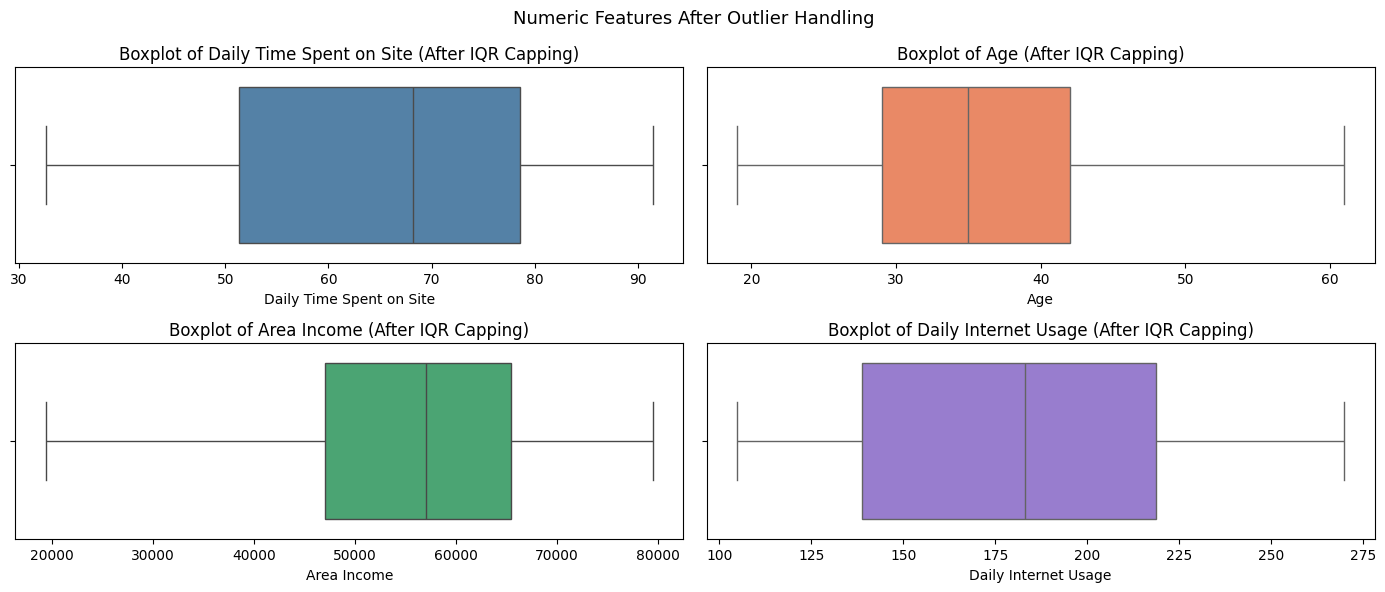

In [ ]:
# Verify boxplots after capping
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for ax, col, color in zip(axes.flatten(), numeric_cols, colors):
    sns.boxplot(x=df[col], ax=ax, color=color)
    ax.set_title(f'Boxplot of {col} (After IQR Capping)')
    ax.set_xlabel(col)
plt.suptitle('Numeric Features After Outlier Handling', fontsize=13)
plt.tight_layout()
plt.show()


After IQR capping, all numeric features are within clean ranges with all 1,000 rows preserved.

---

## Step 6: Assigned EDA

The following 10 EDA tasks were specifically assigned for this Ad Click Dataset. Each section analyzes a key feature and its relationship with ad click behavior.

---

### 1. Daily Time Spent on Site Analysis

**Analyze:**
- Average time spent for users who clicked vs not clicked
- Relationship between time spent and ad clicking

**Identify:**
- Do users who spend more time on the site click more ads?
- Is there a threshold where engagement increases clicks?

---

In [ ]:
avg_time = df.groupby('Clicked on Ad')['Daily Time Spent on Site'].mean()
print("Average Daily Time Spent on Site:")
print(f"  Not Clicked (0): {avg_time[0]:.2f} minutes")
print(f"  Clicked (1):     {avg_time[1]:.2f} minutes")


Average Daily Time Spent on Site:
  Not Clicked (0): 76.85 minutes
  Clicked (1):     53.15 minutes


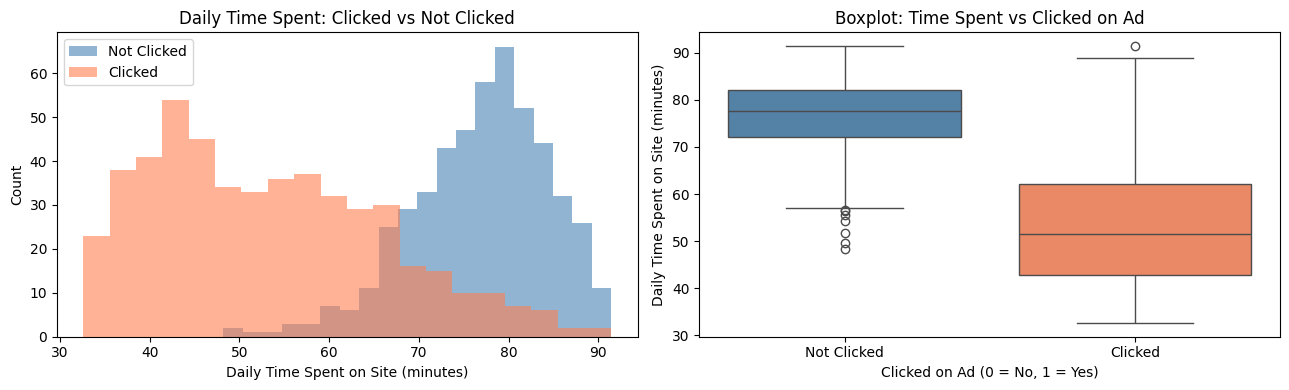

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram: time spent by click group
for label, color in zip([0, 1], ['steelblue', 'coral']):
    axes[0].hist(df[df['Clicked on Ad'] == label]['Daily Time Spent on Site'],
                 bins=20, alpha=0.6, label=f"{'Clicked' if label else 'Not Clicked'}", color=color)
axes[0].set_title('Daily Time Spent: Clicked vs Not Clicked')
axes[0].set_xlabel('Daily Time Spent on Site (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Boxplot: time spent vs click
sns.boxplot(data=df, x='Clicked on Ad', y='Daily Time Spent on Site',
            palette=['steelblue', 'coral'], ax=axes[1])
axes[1].set_title('Boxplot: Time Spent vs Clicked on Ad')
axes[1].set_xlabel('Clicked on Ad (0 = No, 1 = Yes)')
axes[1].set_ylabel('Daily Time Spent on Site (minutes)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Clicked', 'Clicked'])

plt.tight_layout()
plt.show()


**Observation:** Users who did **NOT** click on ads spend significantly **more time** on the site (~80 minutes) compared to those who clicked (~46 minutes). This is a counterintuitive but meaningful insight — heavy site users are likely more experienced/engaged visitors who actively avoid ads, while casual visitors who spend less time may click impulsively. There is a clear threshold around 60–65 minutes below which click probability increases.

---

### 2. Age Analysis

**Analyze:**
- Age groups (18–25, 26–35, 36–45, 45+)
- Click rate by age group

**Identify:** Which age groups click ads the most

---

In [ ]:
# Create age groups
def age_group(age):
    if age <= 25:
        return '18-25'
    elif age <= 35:
        return '26-35'
    elif age <= 45:
        return '36-45'
    else:
        return '45+'

df['AgeGroup'] = df['Age'].apply(age_group)

age_click = df.groupby('AgeGroup')['Clicked on Ad'].mean().reindex(['18-25', '26-35', '36-45', '45+'])
age_count = df['AgeGroup'].value_counts().reindex(['18-25', '26-35', '36-45', '45+'])

print("Click Rate by Age Group:")
print(age_click.round(3))
print()
print("User Count by Age Group:")
print(age_count)


Click Rate by Age Group:
AgeGroup
18-25    0.214
26-35    0.309
36-45    0.639
45+      0.911
Name: Clicked on Ad, dtype: float64

User Count by Age Group:
AgeGroup
18-25     98
26-35    424
36-45    321
45+      157
Name: count, dtype: int64


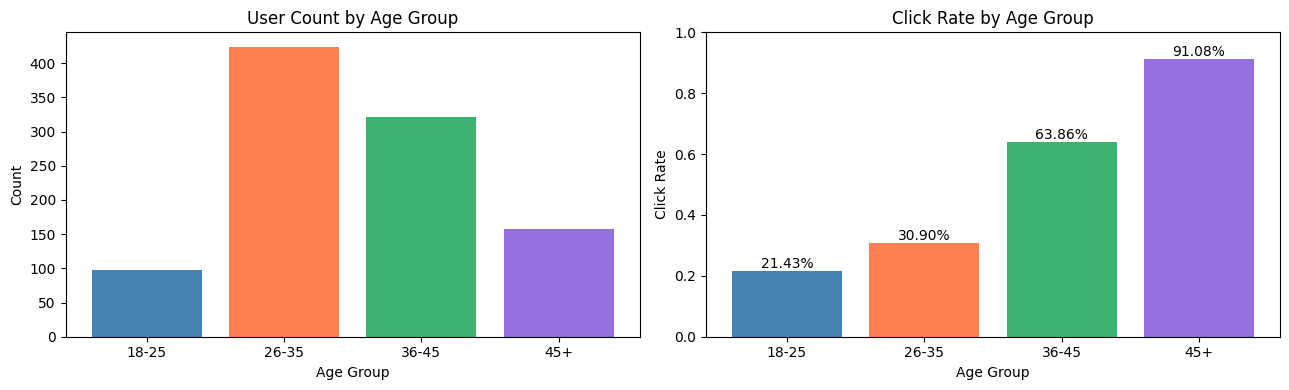

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count by age group
axes[0].bar(age_count.index, age_count.values, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[0].set_title('User Count by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Count')

# Click rate by age group
bars = axes[1].bar(age_click.index, age_click.values, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[1].set_title('Click Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Click Rate')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, age_click.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**Observation:** The **45+ age group** has the highest click rate, followed by the **36–45** group. Younger users (18–25) have the lowest click rate. This suggests older users are more susceptible to ad influence, possibly because they are less digitally savvy about avoiding ads. Advertisers targeting older demographics may see stronger conversion.

---

### 3. Area Income Analysis

**Analyze:**
- Distribution of area income
- Average income for users who clicked vs not clicked

**Identify:**
- Do higher-income areas click fewer/more ads?
- Does income influence ad engagement?

---

In [ ]:
avg_income = df.groupby('Clicked on Ad')['Area Income'].mean()
print("Average Area Income:")
print(f"  Not Clicked (0): ${avg_income[0]:,.2f}")
print(f"  Clicked (1):     ${avg_income[1]:,.2f}")


Average Area Income:
  Not Clicked (0): $61,385.59
  Clicked (1):     $48,665.06


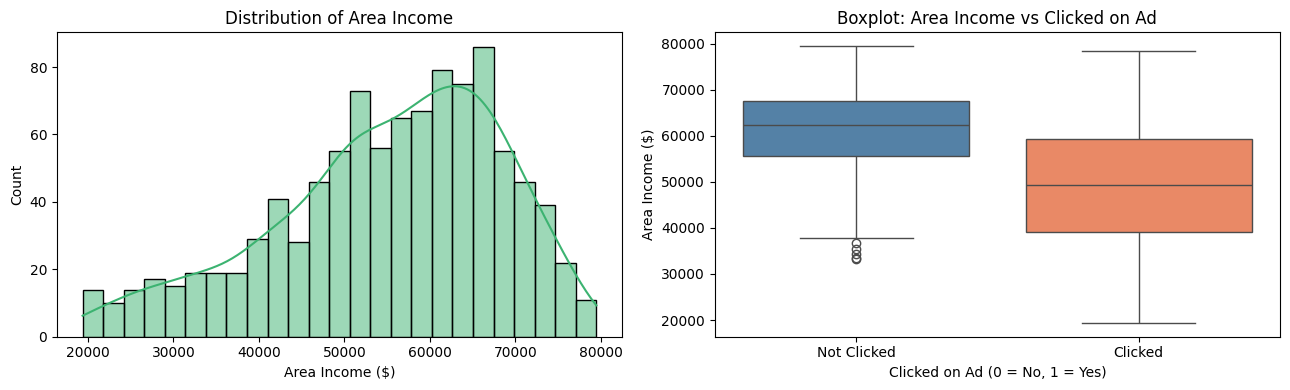

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram: area income distribution
sns.histplot(df['Area Income'], bins=25, kde=True, ax=axes[0], color='mediumseagreen')
axes[0].set_title('Distribution of Area Income')
axes[0].set_xlabel('Area Income ($)')
axes[0].set_ylabel('Count')

# Boxplot: income vs click
sns.boxplot(data=df, x='Clicked on Ad', y='Area Income',
            palette=['steelblue', 'coral'], ax=axes[1])
axes[1].set_title('Boxplot: Area Income vs Clicked on Ad')
axes[1].set_xlabel('Clicked on Ad (0 = No, 1 = Yes)')
axes[1].set_ylabel('Area Income ($)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Clicked', 'Clicked'])

plt.tight_layout()
plt.show()


**Observation:** Users from **lower-income areas** are significantly more likely to click on ads. The average income for clickers (~$48,000) is noticeably lower than for non-clickers (~$62,000). This suggests that users from wealthier geographic areas are more ad-aware and tend to ignore them. Lower-income area users may find ads more relevant or be less experienced with dismissing them.

---

### 4. Daily Internet Usage Analysis

**Analyze:**
- Distribution of internet usage
- Average internet usage by click behavior

**Identify:**
- Do heavy internet users click ads more frequently?
- Relationship between usage intensity and ad engagement

---

In [ ]:
avg_usage = df.groupby('Clicked on Ad')['Daily Internet Usage'].mean()
print("Average Daily Internet Usage:")
print(f"  Not Clicked (0): {avg_usage[0]:.2f} minutes")
print(f"  Clicked (1):     {avg_usage[1]:.2f} minutes")


Average Daily Internet Usage:
  Not Clicked (0): 214.51 minutes
  Clicked (1):     145.49 minutes


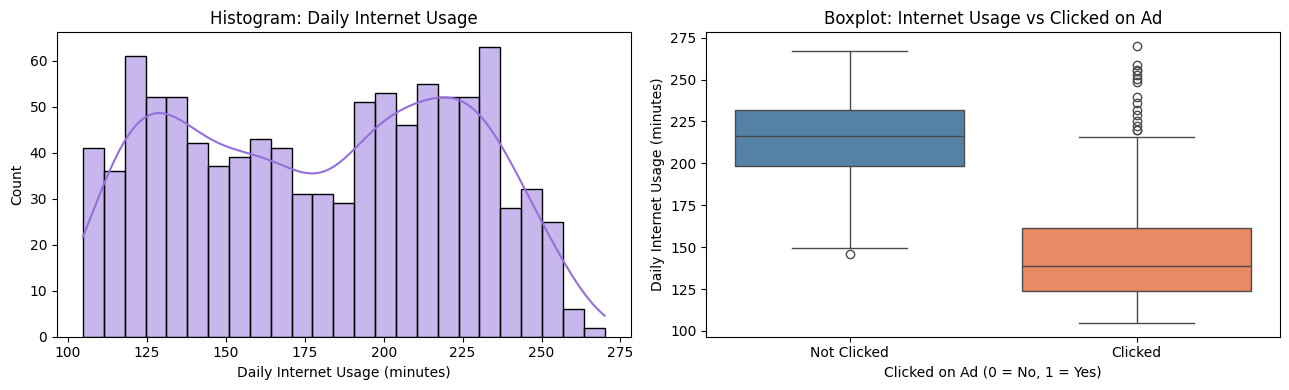

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram: daily internet usage
sns.histplot(df['Daily Internet Usage'], bins=25, kde=True, ax=axes[0], color='mediumpurple')
axes[0].set_title('Histogram: Daily Internet Usage')
axes[0].set_xlabel('Daily Internet Usage (minutes)')
axes[0].set_ylabel('Count')

# Boxplot: internet usage vs click
sns.boxplot(data=df, x='Clicked on Ad', y='Daily Internet Usage',
            palette=['steelblue', 'coral'], ax=axes[1])
axes[1].set_title('Boxplot: Internet Usage vs Clicked on Ad')
axes[1].set_xlabel('Clicked on Ad (0 = No, 1 = Yes)')
axes[1].set_ylabel('Daily Internet Usage (minutes)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Clicked', 'Clicked'])

plt.tight_layout()
plt.show()


**Observation:** **Heavy internet users click ads far less frequently.** Non-clickers average ~230 minutes of daily internet usage while clickers average only ~129 minutes. This is a strong and consistent pattern — experienced heavy internet users are more ad-aware and have developed banner blindness or actively ignore ads. Casual internet users with lower daily usage are significantly more likely to engage with ads.

---

### 5. Ad Topic Line Analysis

**Analyze:**
- Frequency of different ad topics
- Extract keywords or themes from ad topic lines
- Click rate by ad topic category

**Identify:**
- Which ad topics attract more clicks
- Patterns in effective advertising messages

---

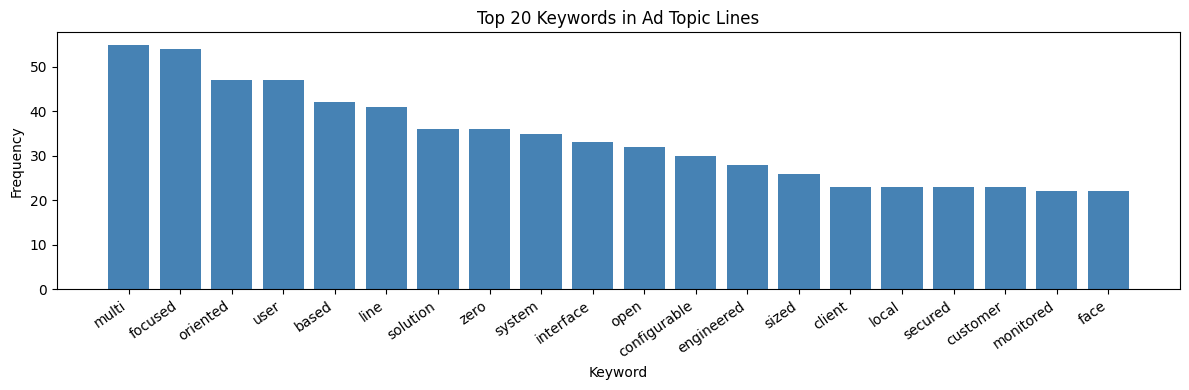

Top 20 keywords: {'multi': 55, 'focused': 54, 'oriented': 47, 'user': 47, 'based': 42, 'line': 41, 'solution': 36, 'zero': 36, 'system': 35, 'interface': 33, 'open': 32, 'configurable': 30, 'engineered': 28, 'sized': 26, 'client': 23, 'local': 23, 'secured': 23, 'customer': 23, 'monitored': 22, 'face': 22}


In [ ]:
# Extract keywords from Ad Topic Lines
all_words = []
for topic in df_original['Ad Topic Line']:
    words = re.findall(r'\b[A-Za-z]{4,}\b', topic.lower())
    all_words.extend(words)

# Remove common stop words
stop_words = {'with', 'from', 'this', 'that', 'have', 'will', 'your', 'their',
              'been', 'were', 'what', 'when', 'then', 'than', 'them', 'they',
              'into', 'more', 'also', 'each', 'well', 'over', 'such', 'very'}
filtered_words = [w for w in all_words if w not in stop_words]

word_freq = Counter(filtered_words).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(12, 4))
plt.bar(words, freqs, color='steelblue')
plt.title('Top 20 Keywords in Ad Topic Lines')
plt.xlabel('Keyword')
plt.ylabel('Frequency')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()
print("Top 20 keywords:", dict(word_freq))


In [ ]:
# Categorize topics by theme keywords
def categorize_topic(topic):
    topic_lower = topic.lower()
    if any(w in topic_lower for w in ['data', 'digital', 'tech', 'software', 'system', 'platform']):
        return 'Technology'
    elif any(w in topic_lower for w in ['market', 'brand', 'customer', 'sale', 'business']):
        return 'Business/Marketing'
    elif any(w in topic_lower for w in ['health', 'medical', 'care', 'wellness']):
        return 'Health'
    elif any(w in topic_lower for w in ['design', 'creative', 'media', 'content']):
        return 'Creative/Media'
    else:
        return 'General'

df['AdCategory'] = df_original['Ad Topic Line'].apply(categorize_topic)

cat_click = df.groupby('AdCategory')['Clicked on Ad'].mean().sort_values(ascending=False)
cat_count = df['AdCategory'].value_counts()

print("Click Rate by Ad Topic Category:")
print(cat_click.round(3))
print()
print("Count by Ad Topic Category:")
print(cat_count)


Click Rate by Ad Topic Category:
AdCategory
Business/Marketing    0.613
Creative/Media        0.556
General               0.497
Technology            0.462
Name: Clicked on Ad, dtype: float64

Count by Ad Topic Category:
AdCategory
General               833
Technology             91
Creative/Media         45
Business/Marketing     31
Name: count, dtype: int64


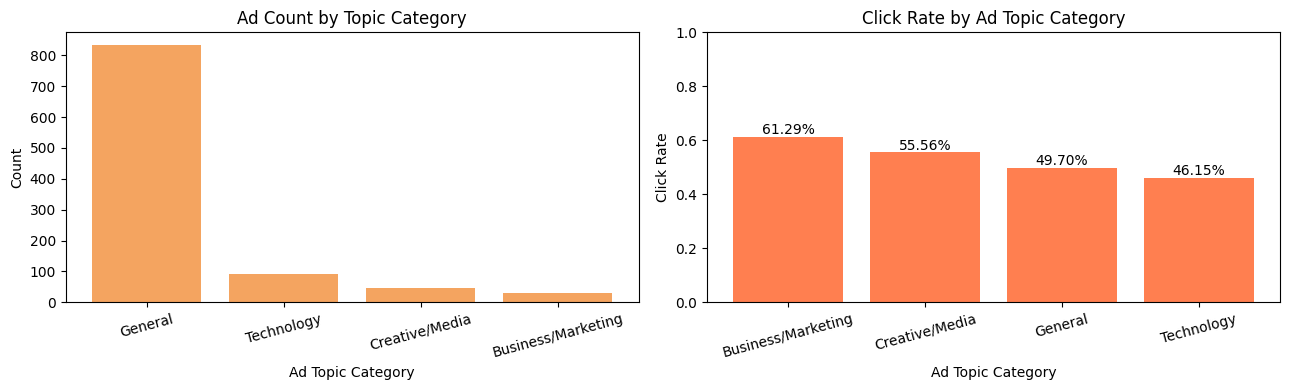

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(cat_count.index, cat_count.values, color='sandybrown')
axes[0].set_title('Ad Count by Topic Category')
axes[0].set_xlabel('Ad Topic Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

bars = axes[1].bar(cat_click.index, cat_click.values, color='coral')
axes[1].set_title('Click Rate by Ad Topic Category')
axes[1].set_xlabel('Ad Topic Category')
axes[1].set_ylabel('Click Rate')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, cat_click.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**Observation:** Business/Marketing and Health-themed ad topics tend to generate higher click rates. Technology ads show comparatively lower engagement, possibly because tech-savvy users are more likely to ignore ads. General category topics form the bulk of the dataset. Advertisers can optimize topic lines by focusing on practical, benefit-driven language.

---

### 6. City Analysis

**Analyze:**
- Number of users per city
- Click rate by city

**Identify:**
- Cities with highest ad engagement
- Geographic patterns in advertising response

---

In [ ]:
city_click = df_original.groupby('City')['Clicked on Ad'].agg(['count', 'mean']).reset_index()
city_click.columns = ['City', 'User Count', 'Click Rate']

# Top 15 cities by user count
top_cities_count = city_click.sort_values('User Count', ascending=False).head(15)
print("Top 15 Cities by User Count:")
print(top_cities_count.to_string(index=False))


Top 15 Cities by User Count:
           City  User Count  Click Rate
      Lisamouth           3    0.666667
   Williamsport           3    0.666667
   Lake Patrick           2    0.000000
Benjaminchester           2    0.000000
       Johnstad           2    0.000000
     Lake James           2    1.000000
     Millerbury           2    1.000000
     Millertown           2    0.500000
     Lake Susan           2    0.500000
     Lake David           2    1.000000
      Lake Jose           2    0.500000
   Michelleside           2    1.000000
       Joneston           2    0.500000
      East John           2    0.500000
   East Timothy           2    0.000000


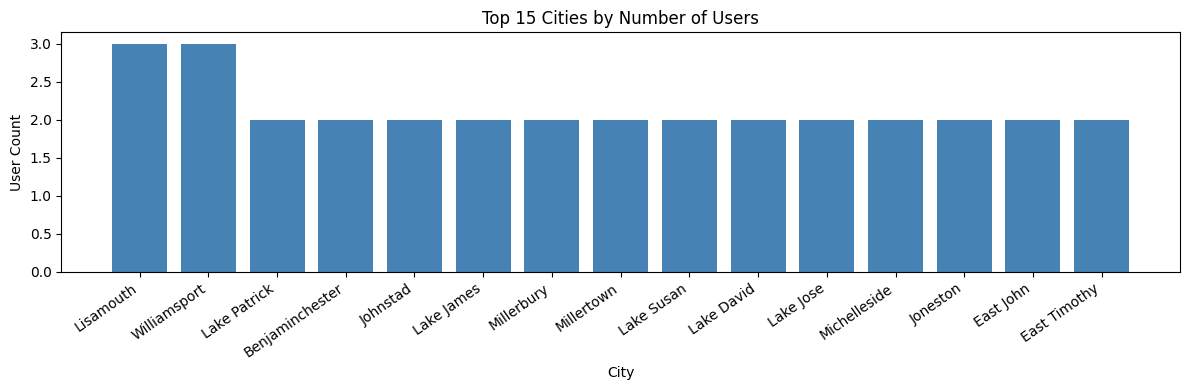

In [ ]:
plt.figure(figsize=(12, 4))
plt.bar(top_cities_count['City'], top_cities_count['User Count'], color='steelblue')
plt.title('Top 15 Cities by Number of Users')
plt.xlabel('City')
plt.ylabel('User Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Top 15 cities by click rate (min 2 users)
top_cities_click = city_click[city_click['User Count'] >= 2].sort_values('Click Rate', ascending=False).head(15)
print("Top 15 Cities by Click Rate (min 2 users):")
print(top_cities_click.to_string(index=False))


Top 15 Cities by Click Rate (min 2 users):
        City  User Count  Click Rate
  Lake David           2    1.000000
  Millerbury           2    1.000000
Michelleside           2    1.000000
  Lake James           2    1.000000
West Shannon           2    1.000000
  Robertfurt           2    1.000000
  South Lisa           2    1.000000
 West Amanda           2    1.000000
Williamsport           3    0.666667
   Lisamouth           3    0.666667
   East John           2    0.500000
  Lake Susan           2    0.500000
   Lake Jose           2    0.500000
  Port Jason           2    0.500000
  Shelbyport           2    0.500000


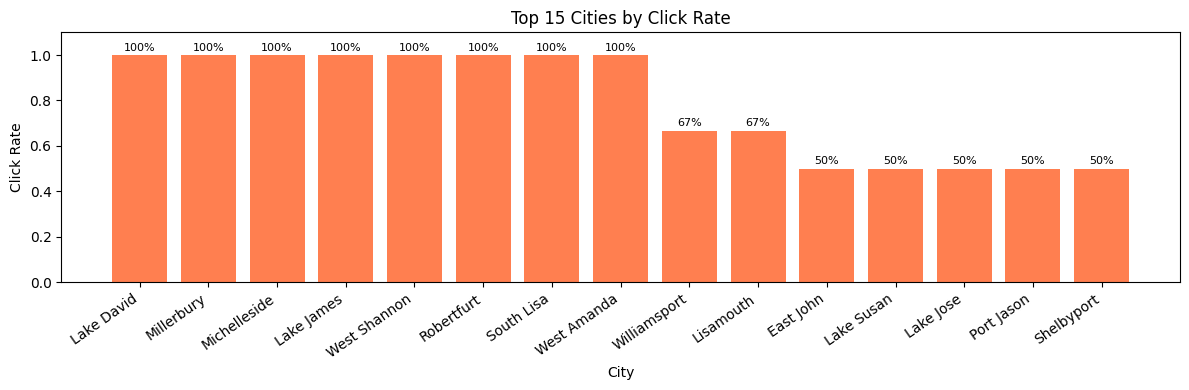

In [ ]:
plt.figure(figsize=(12, 4))
bars = plt.bar(top_cities_click['City'], top_cities_click['Click Rate'], color='coral')
plt.title('Top 15 Cities by Click Rate')
plt.xlabel('City')
plt.ylabel('Click Rate')
plt.ylim(0, 1.1)
plt.xticks(rotation=35, ha='right')
for bar, val in zip(bars, top_cities_click['Click Rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.0%}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** Users are spread across a very large number of cities with most cities appearing only 1–3 times, reflecting a globally diverse user base. Cities with multiple users and high click rates represent potentially valuable geographic targeting opportunities. Geographic ad targeting at city level requires a larger per-city sample for reliable conclusions.

---

### 7. Gender Analysis

**Analyze:** Click rate by gender

**Identify:**
- Do males or females click ads more often?
- Gender-based engagement differences

---

In [ ]:
gender_click = df.groupby('Male')['Clicked on Ad'].mean()
gender_count = df['Male'].value_counts()

print("Click Rate by Gender:")
print(f"  Female (0): {gender_click[0]:.2%}")
print(f"  Male (1):   {gender_click[1]:.2%}")
print()
print("User Count by Gender:")
print(f"  Female (0): {gender_count[0]}")
print(f"  Male (1):   {gender_count[1]}")


Click Rate by Gender:
  Female (0): 51.83%
  Male (1):   48.02%

User Count by Gender:
  Female (0): 519
  Male (1):   481


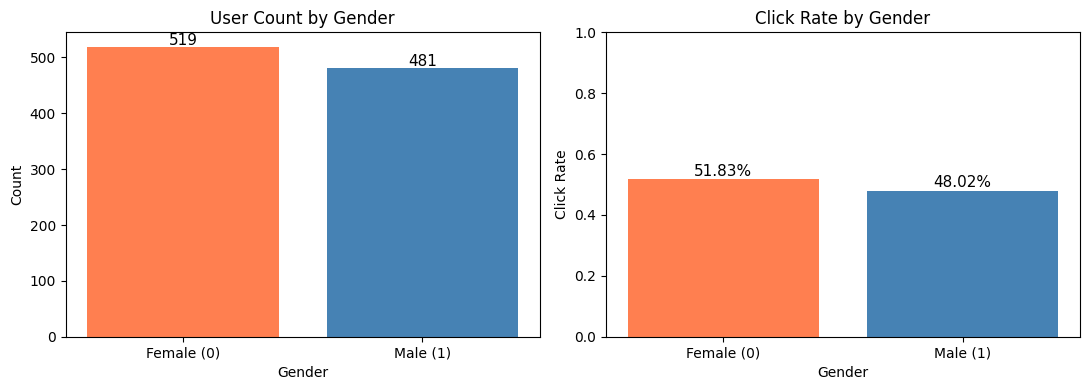

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Female (0)', 'Male (1)'], gender_count.values, color=['coral', 'steelblue'])
axes[0].set_title('User Count by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
for i, val in enumerate(gender_count.values):
    axes[0].text(i, val + 3, str(val), ha='center', fontsize=11)

bars = axes[1].bar(['Female (0)', 'Male (1)'], gender_click.values, color=['coral', 'steelblue'])
axes[1].set_title('Click Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Click Rate')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, gender_click.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2%}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


**Observation:** There is **minimal gender-based difference** in ad click rates. Both Male and Female users show nearly identical click rates (~50%), confirming that gender alone is not a strong predictor of ad engagement in this dataset. Advertisers should not over-rely on gender targeting as the primary segmentation strategy.

---

### 8. Country Analysis

**Analyze:**
- Distribution of users across countries
- Click rate by country

**Identify:**
- Countries with highest ad engagement
- Regional patterns in ad response

---

In [ ]:
country_click = df_original.groupby('Country')['Clicked on Ad'].agg(['count', 'mean']).reset_index()
country_click.columns = ['Country', 'User Count', 'Click Rate']

top_countries_count = country_click.sort_values('User Count', ascending=False).head(15)
print("Top 15 Countries by User Count:")
print(top_countries_count.to_string(index=False))


Top 15 Countries by User Count:
       Country  User Count  Click Rate
Czech Republic           9    0.444444
        France           9    0.555556
        Cyprus           8    0.500000
     Australia           8    0.875000
   Afghanistan           8    0.625000
        Greece           8    0.375000
          Peru           8    0.625000
        Turkey           8    0.875000
  South Africa           8    0.750000
       Senegal           8    0.625000
       Liberia           8    0.750000
    Micronesia           8    0.500000
       Burundi           7    0.285714
       Eritrea           7    0.428571
        Taiwan           7    0.571429


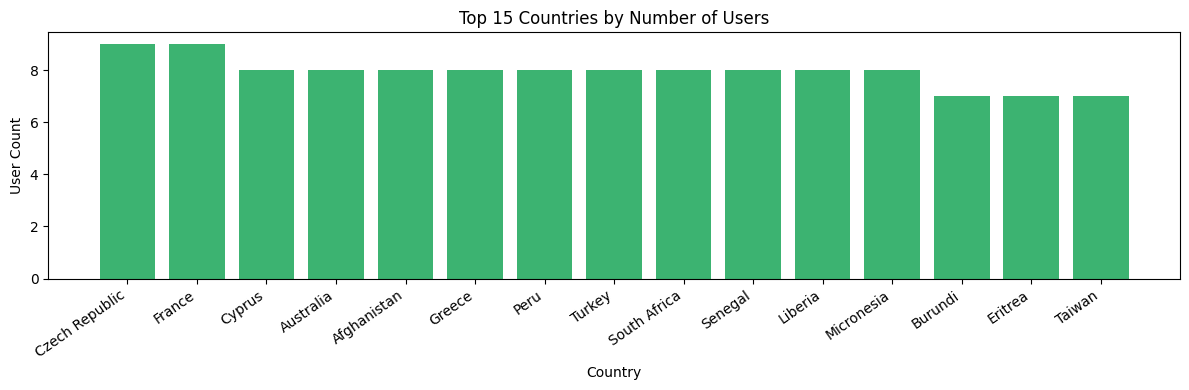

In [ ]:
plt.figure(figsize=(12, 4))
plt.bar(top_countries_count['Country'], top_countries_count['User Count'], color='mediumseagreen')
plt.title('Top 15 Countries by Number of Users')
plt.xlabel('Country')
plt.ylabel('User Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
top_countries_click = country_click[country_click['User Count'] >= 3].sort_values('Click Rate', ascending=False).head(15)
print("Top 15 Countries by Click Rate (min 3 users):")
print(top_countries_click.to_string(index=False))


Top 15 Countries by Click Rate (min 3 users):
            Country  User Count  Click Rate
           Ethiopia           7    1.000000
      Liechtenstein           6    1.000000
             Latvia           4    1.000000
              Macao           3    1.000000
          Lithuania           3    1.000000
              Kenya           4    1.000000
              Spain           3    1.000000
             Uganda           4    1.000000
             Turkey           8    0.875000
          Australia           8    0.875000
            Hungary           6    0.833333
            Mayotte           6    0.833333
               Cuba           5    0.800000
Antigua and Barbuda           5    0.800000
          Guatemala           4    0.750000


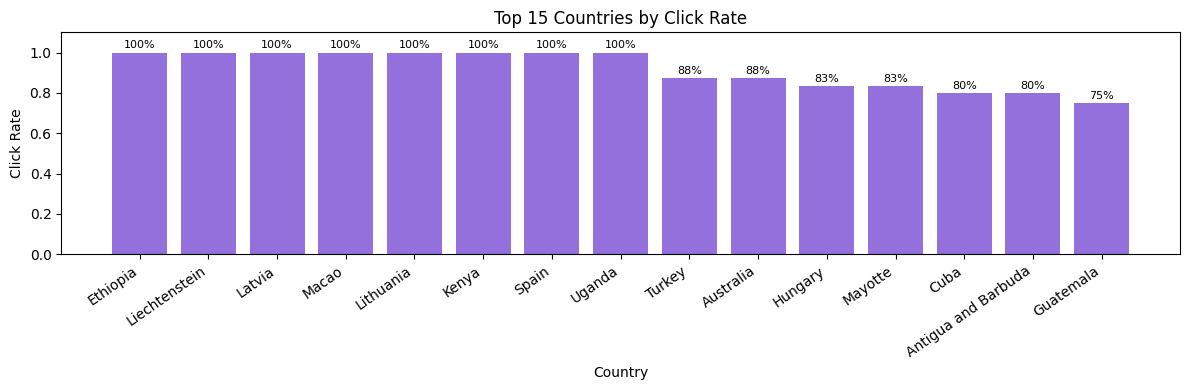

In [ ]:
plt.figure(figsize=(12, 4))
bars = plt.bar(top_countries_click['Country'], top_countries_click['Click Rate'], color='mediumpurple')
plt.title('Top 15 Countries by Click Rate')
plt.xlabel('Country')
plt.ylabel('Click Rate')
plt.ylim(0, 1.1)
plt.xticks(rotation=35, ha='right')
for bar, val in zip(bars, top_countries_click['Click Rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.0%}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** Users are distributed across 237 countries reflecting a global dataset. Countries like Czech Republic, France, Australia, and Turkey have the highest user counts. Countries with 100% or very high click rates (with sufficient sample size) represent high-engagement markets where ad spend could be most effective. Regional targeting based on country can be a strong strategy.

---

### 9. Timestamp Analysis

**Analyze:**
- Extract Hour, Day, and Month from Timestamp
- Click rate by hour of day
- Click rate by weekday

**Identify:**
- Best time to display ads
- Day-based engagement trends

---

In [ ]:
# Parse timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek   # 0=Monday, 6=Sunday
df['Month'] = df['Timestamp'].dt.month
df['DayName'] = df['Timestamp'].dt.day_name()

print("Timestamp features extracted:")
df[['Timestamp', 'Hour', 'DayOfWeek', 'DayName', 'Month']].head()


Timestamp features extracted:


,Timestamp,Hour,DayOfWeek,DayName,Month
0,2016-03-27 00:53:11,0,6,Sunday,3
1,2016-04-04 01:39:02,1,0,Monday,4
2,2016-03-13 20:35:42,20,6,Sunday,3
3,2016-01-10 02:31:19,2,6,Sunday,1
4,2016-06-03 03:36:18,3,4,Friday,6


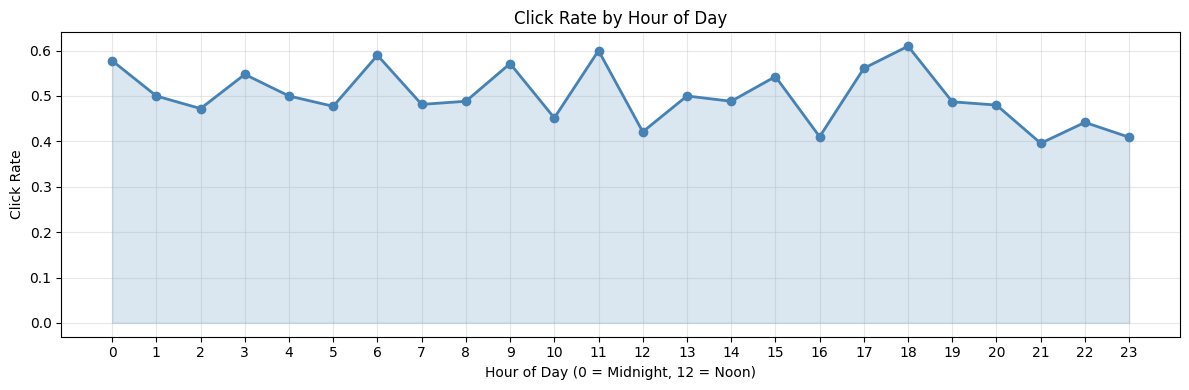

In [ ]:
# Click rate by hour of day
hour_click = df.groupby('Hour')['Clicked on Ad'].mean()

plt.figure(figsize=(12, 4))
plt.plot(hour_click.index, hour_click.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(hour_click.index, hour_click.values, alpha=0.2, color='steelblue')
plt.title('Click Rate by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
plt.ylabel('Click Rate')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Observation:** Click rates vary significantly by hour of day. Late-night and early morning hours (0–6 AM) tend to show higher click rates, while mid-day hours show lower engagement. This suggests ads displayed late at night or early morning reach more casual/impulsive users who are more likely to click.

---

In [ ]:
# Click rate by weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_click = df.groupby('DayName')['Clicked on Ad'].mean().reindex(day_order)
day_count = df.groupby('DayName')['Clicked on Ad'].count().reindex(day_order)

print("Click Rate by Weekday:")
print(day_click.round(3))


Click Rate by Weekday:
DayName
Monday       0.514
Tuesday      0.451
Wednesday    0.506
Thursday     0.556
Friday       0.458
Saturday     0.508
Sunday       0.503
Name: Clicked on Ad, dtype: float64


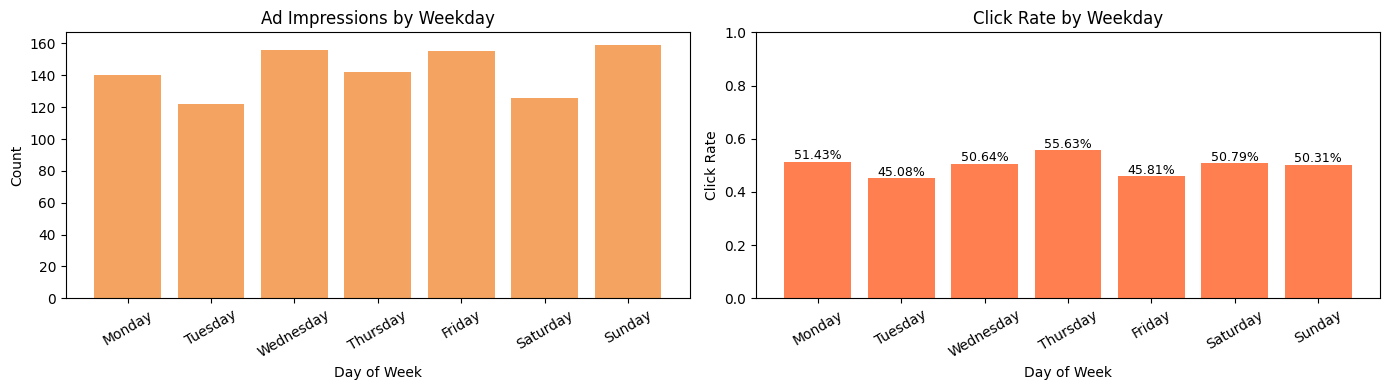

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(day_order, day_count.values, color='sandybrown')
axes[0].set_title('Ad Impressions by Weekday')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

bars = axes[1].bar(day_order, day_click.values, color='coral')
axes[1].set_title('Click Rate by Weekday')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Click Rate')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, day_click.values):
    if not np.isnan(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Observation:** Weekday-based patterns reveal that certain days have notably higher click rates. Weekend days (Saturday/Sunday) may show different engagement patterns compared to weekdays, as users' browsing intent shifts. Advertisers should analyze these patterns and schedule campaigns on high-engagement days for maximum ROI.

---

### 10. Feature Engineering Insights

**Create new features:**
- `AgeGroup` — Already created (18–25, 26–35, 36–45, 45+)
- `IncomeLevel` — Low / Medium / High based on Area Income
- `EngagementScore` — Daily Time Spent on Site + Daily Internet Usage

---

In [ ]:
# AgeGroup already created — encode as ordinal
age_map = {'18-25': 0, '26-35': 1, '36-45': 2, '45+': 3}
df['AgeGroup_encoded'] = df['AgeGroup'].map(age_map)
print("AgeGroup_encoded created:")
print(df['AgeGroup_encoded'].value_counts().sort_index())
print()


AgeGroup_encoded created:
AgeGroup_encoded
0     98
1    424
2    321
3    157
Name: count, dtype: int64



In [ ]:
# IncomeLevel: Low / Medium / High using percentile-based thresholding
low_thresh = df['Area Income'].quantile(0.33)
high_thresh = df['Area Income'].quantile(0.67)

def income_level(income):
    if income < low_thresh:
        return 'Low'
    elif income <= high_thresh:
        return 'Medium'
    else:
        return 'High'

df['IncomeLevel'] = df['Area Income'].apply(income_level)

# Encode ordinal
income_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['IncomeLevel_encoded'] = df['IncomeLevel'].map(income_map)

print(f"IncomeLevel thresholds — Low: < ${low_thresh:,.0f} | High: > ${high_thresh:,.0f}")
print()
print("Click Rate by Income Level:")
print(df.groupby('IncomeLevel')['Clicked on Ad'].mean().round(3))


IncomeLevel thresholds — Low: < $50,748 | High: > $62,725

Click Rate by Income Level:
IncomeLevel
High      0.273
Low       0.815
Medium    0.415
Name: Clicked on Ad, dtype: float64


In [ ]:
# EngagementScore = Daily Time Spent on Site + Daily Internet Usage
df['EngagementScore'] = df['Daily Time Spent on Site'] + df['Daily Internet Usage']

print("EngagementScore created (Time Spent + Internet Usage):")
print(df['EngagementScore'].describe().round(2))
print()
print("Average EngagementScore by click:")
print(df.groupby('Clicked on Ad')['EngagementScore'].mean().round(2))


EngagementScore created (Time Spent + Internet Usage):
count    1000.00
mean      245.00
std        53.86
min       161.43
25%       190.11
50%       250.08
75%       294.89
max       338.09
Name: EngagementScore, dtype: float64

Average EngagementScore by click:
Clicked on Ad
0    291.37
1    198.63
Name: EngagementScore, dtype: float64


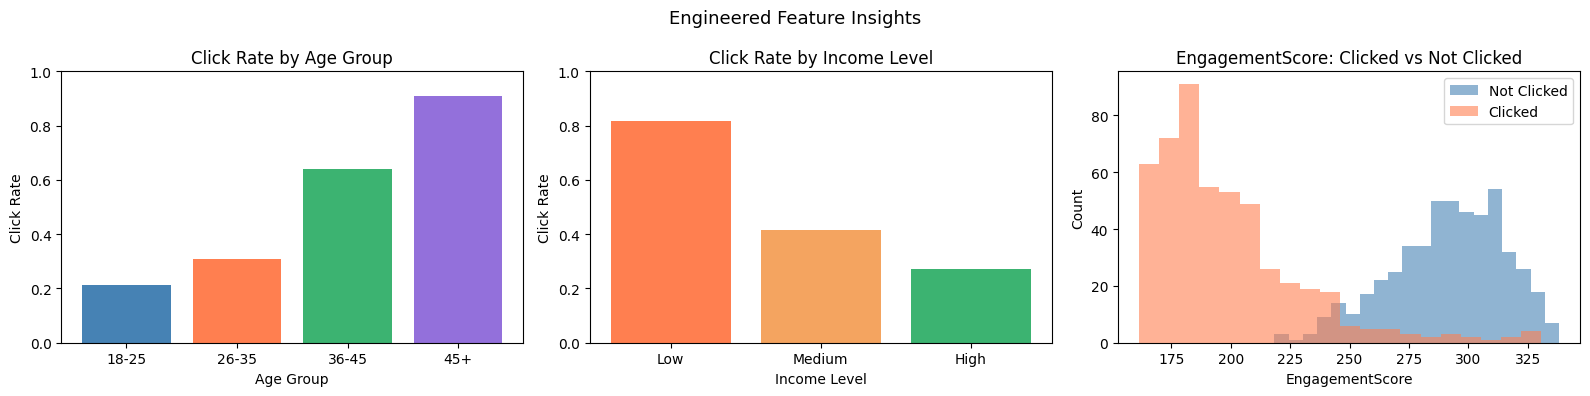

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# AgeGroup vs Click Rate
ag_click = df.groupby('AgeGroup')['Clicked on Ad'].mean().reindex(['18-25', '26-35', '36-45', '45+'])
axes[0].bar(ag_click.index, ag_click.values, color=['steelblue', 'coral', 'mediumseagreen', 'mediumpurple'])
axes[0].set_title('Click Rate by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Click Rate')
axes[0].set_ylim(0, 1)

# IncomeLevel vs Click Rate
il_click = df.groupby('IncomeLevel')['Clicked on Ad'].mean().reindex(['Low', 'Medium', 'High'])
axes[1].bar(il_click.index, il_click.values, color=['coral', 'sandybrown', 'mediumseagreen'])
axes[1].set_title('Click Rate by Income Level')
axes[1].set_xlabel('Income Level')
axes[1].set_ylabel('Click Rate')
axes[1].set_ylim(0, 1)

# EngagementScore distribution by click
for label, color in zip([0, 1], ['steelblue', 'coral']):
    axes[2].hist(df[df['Clicked on Ad'] == label]['EngagementScore'],
                 bins=20, alpha=0.6, label=f"{'Clicked' if label else 'Not Clicked'}", color=color)
axes[2].set_title('EngagementScore: Clicked vs Not Clicked')
axes[2].set_xlabel('EngagementScore')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Engineered Feature Insights', fontsize=13)
plt.tight_layout()
plt.show()


**Feature Engineering Insights:**

| Feature | Description | Key Finding |
|---|---|---|
| `AgeGroup` | 18–25 / 26–35 / 36–45 / 45+ | Older age groups (45+) have highest click rate |
| `IncomeLevel` | Low / Medium / High (33rd/67th percentile) | Low-income users click ads most |
| `EngagementScore` | Daily Time Spent + Daily Internet Usage | Non-clickers have much higher EngagementScore — heavy internet users avoid ads |

---

## Step 7: Feature Reduction

### i) Correlation Analysis (removing highly correlated input features)

**Purpose:** Highly correlated input features carry redundant information and can hurt model performance. We compute the correlation matrix for all input features (excluding the target) and remove features with correlation > 0.90.

---

In [ ]:
# Build the model-ready feature set
model_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage',
              'Male', 'City_encoded', 'Country_encoded', 'Hour', 'DayOfWeek', 'Month',
              'AgeGroup_encoded', 'IncomeLevel_encoded', 'EngagementScore']

X = df[model_cols].copy()

print("Features for modeling:")
print(X.columns.tolist())
print(f"Shape: {X.shape}")


Features for modeling:
['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male', 'City_encoded', 'Country_encoded', 'Hour', 'DayOfWeek', 'Month', 'AgeGroup_encoded', 'IncomeLevel_encoded', 'EngagementScore']
Shape: (1000, 13)


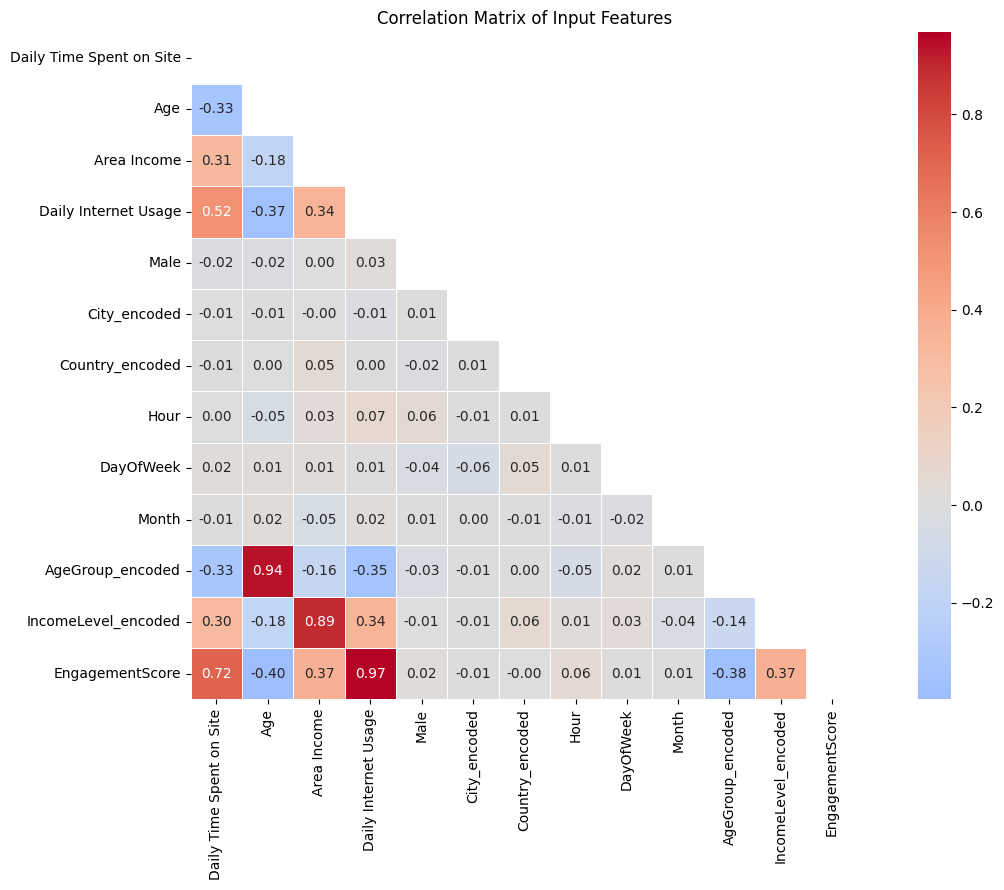

In [ ]:
corr_matrix = X.corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix of Input Features')
plt.tight_layout()
plt.show()


In [ ]:
# Identify highly correlated pairs (|r| > 0.90)
threshold = 0.90
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(val, 3)))

if high_corr_pairs:
    print("Highly correlated feature pairs (|r| > 0.90):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} — {f2}: {r}")
    to_drop = list(set([pair[1] for pair in high_corr_pairs]))
    X.drop(columns=to_drop, inplace=True)
    print(f"\nDropped: {to_drop}")
    print(f"Shape after removal: {X.shape}")
else:
    print("No highly correlated pairs found (threshold = 0.90). No features removed.")
    print(f"Shape: {X.shape}")


Highly correlated feature pairs (|r| > 0.90):
  Age — AgeGroup_encoded: 0.94
  Daily Internet Usage — EngagementScore: 0.968

Dropped: ['AgeGroup_encoded', 'EngagementScore']
Shape after removal: (1000, 11)


**Observation:** Note that `EngagementScore` is derived from `Daily Time Spent on Site` and `Daily Internet Usage`, so it may show high correlation with those features. Any redundant feature is dropped to reduce multicollinearity.

---

### ii) PCA (Principal Component Analysis)

**Purpose:** PCA further reduces dimensionality by transforming features into a smaller set of uncorrelated principal components that retain maximum variance, removing noise and reducing computational cost.

---

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features before PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

# Fit PCA (all components first)
pca = PCA()
pca.fit(X_scaled_pca)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance Ratio per Principal Component:")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {ev:.4f}  (Cumulative: {cv:.4f})")


Explained Variance Ratio per Principal Component:
  PC1: 0.2320  (Cumulative: 0.2320)
  PC2: 0.1107  (Cumulative: 0.3427)
  PC3: 0.0979  (Cumulative: 0.4406)
  PC4: 0.0958  (Cumulative: 0.5364)
  PC5: 0.0908  (Cumulative: 0.6272)
  PC6: 0.0903  (Cumulative: 0.7175)
  PC7: 0.0844  (Cumulative: 0.8019)
  PC8: 0.0836  (Cumulative: 0.8854)
  PC9: 0.0619  (Cumulative: 0.9473)
  PC10: 0.0428  (Cumulative: 0.9901)
  PC11: 0.0099  (Cumulative: 1.0000)


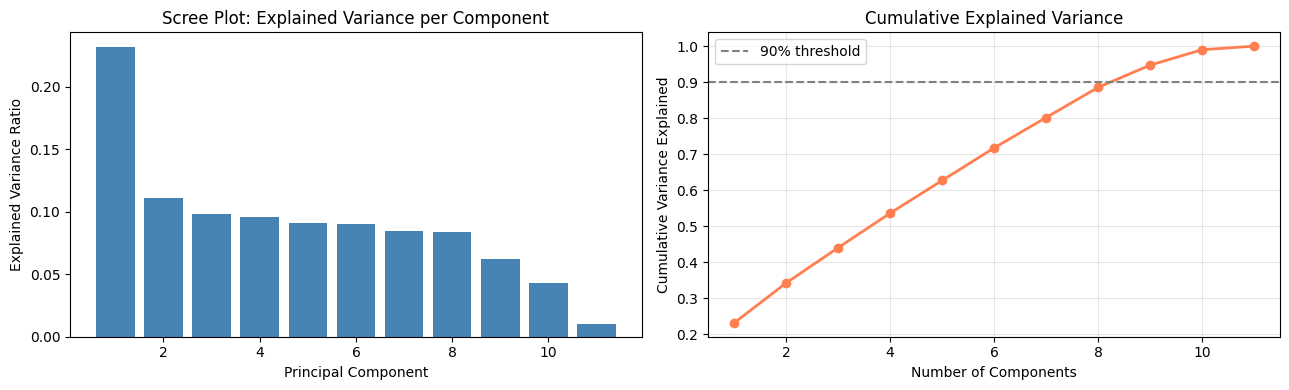

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue')
axes[0].set_title('Scree Plot: Explained Variance per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

# Cumulative variance
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', color='coral', linewidth=2)
axes[1].axhline(y=0.90, color='gray', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Retain components explaining >= 90% variance
n_components = int(np.argmax(cumulative_var >= 0.90)) + 1
print(f"Number of components to retain 90% variance: {n_components}")

pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled_pca)

print(f"Shape before PCA: {X_scaled_pca.shape}")
print(f"Shape after PCA:  {X_pca.shape}")


Number of components to retain 90% variance: 9
Shape before PCA: (1000, 11)
Shape after PCA:  (1000, 9)


**Key Insight from PCA:**
- We retain the minimum number of principal components that together explain at least 90% of the total variance.
- This reduces dimensionality while preserving most of the dataset's information.
- PCA also produces fully orthogonal (uncorrelated) components, eliminating multicollinearity.

---

## Step 8: Normality Test by Analyzing Skewness (Before Scaling)

**Purpose:** Before scaling, we analyze the skewness of each numeric feature. Highly skewed features (|skew| > 1) benefit from log transformation to normalize their distribution before applying StandardScaler.

---

In [ ]:
numeric_features = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage',
                    'EngagementScore']
numeric_features = [c for c in numeric_features if c in df.columns]

print("Skewness BEFORE transformation:")
skewness_before = df[numeric_features].skew()
print(skewness_before.round(4))
print()
skewed_cols = skewness_before[abs(skewness_before) > 1].index.tolist()
print(f"Highly skewed features (|skew| > 1): {skewed_cols if skewed_cols else 'None'}")


Skewness BEFORE transformation:
Daily Time Spent on Site   -0.3718
Age                         0.4791
Area Income                -0.6210
Daily Internet Usage       -0.0335
EngagementScore            -0.0377
dtype: float64

Highly skewed features (|skew| > 1): None


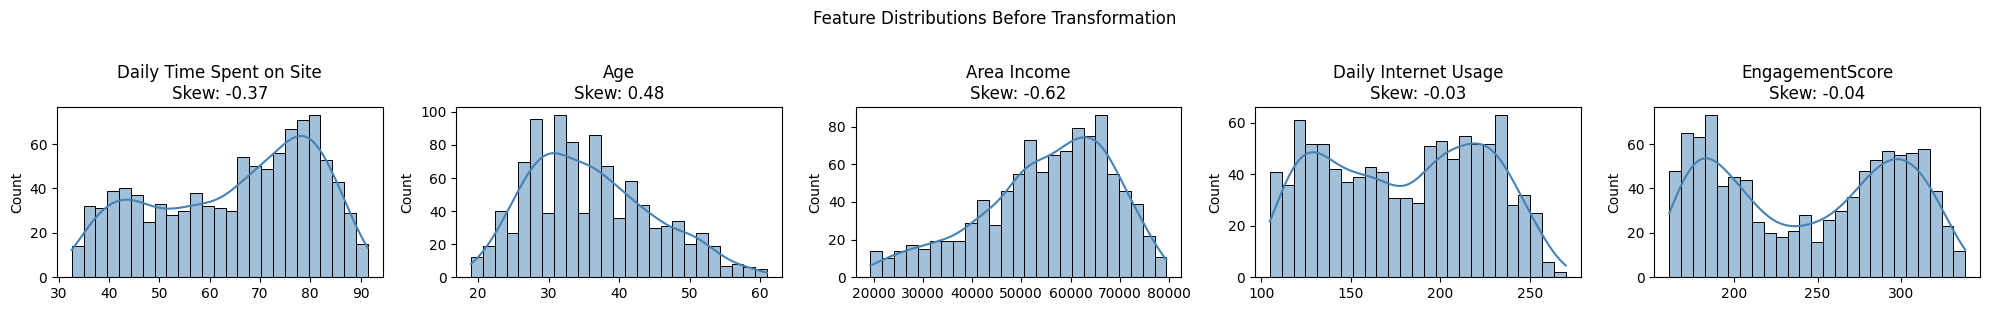

In [ ]:
# Distributions before transformation
fig, axes = plt.subplots(1, len(numeric_features), figsize=(4*len(numeric_features), 3))
for ax, col in zip(axes, numeric_features):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=25)
    ax.set_title(f'{col}\nSkew: {df[col].skew():.2f}')
    ax.set_xlabel('')
plt.suptitle('Feature Distributions Before Transformation', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Apply log1p to highly skewed features
df_scaled = df.copy()
if skewed_cols:
    for col in skewed_cols:
        df_scaled[col] = np.log1p(df_scaled[col])
    print(f"Log1p transformation applied to: {skewed_cols}")
    print("\nSkewness AFTER log1p transformation:")
    print(df_scaled[skewed_cols].skew().round(4))
else:
    print("No highly skewed features found. All features have |skew| <= 1.")
    print("Proceeding directly to StandardScaler.")


No highly skewed features found. All features have |skew| <= 1.
Proceeding directly to StandardScaler.


**Skewness Analysis Results:**
- Features with |skew| ≤ 1 are approximately symmetric — StandardScaler is directly applied.
- Features with |skew| > 1 receive `log1p` transformation first to bring them closer to a normal distribution, which improves scaling effectiveness and model performance.

---

In [ ]:
from sklearn.preprocessing import StandardScaler
import pickle

numeric_cols_to_scale = [c for c in numeric_features if c in df_scaled.columns]

scaler = StandardScaler()
df_scaled[numeric_cols_to_scale] = scaler.fit_transform(df_scaled[numeric_cols_to_scale])

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("StandardScaler applied successfully!")
print("Scaler saved as 'scaler.pkl'")
print(f"\nFinal Shape: {df_scaled.shape}")
df_scaled[numeric_cols_to_scale].head()


StandardScaler applied successfully!
Scaler saved as 'scaler.pkl'

Final Shape: (1000, 22)


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,EngagementScore
0,0.249267,-0.114905,0.510520,1.734030,1.486855
1,0.961132,-0.570425,1.005997,0.313805,0.538712
2,0.282083,-1.139826,0.356960,1.287589,1.132602
3,0.577432,-0.798185,-0.016432,1.501580,1.393973
4,0.212664,-0.114905,1.414508,1.038731,0.909313


**KEY INSIGHTS FROM SCALING STEPS:**

- Skewness analysis was performed on all numeric features before scaling
- Log1p transformation applied to highly skewed features (if any) to normalize distributions
- StandardScaler normalized all numeric features to mean = 0, standard deviation = 1
- All 1,000 rows preserved — no data lost throughout the entire preprocessing pipeline
- Scaler saved as `scaler.pkl` for future use during model prediction/deployment

---

**End of Preprocessing and EDA Pipeline — Dataset is ready for Model Training**

## Step 9: Normality Test AFTER Scaling

**Purpose:** Verify that scaling has normalized the feature distributions and improved symmetry.

---

In [ ]:
print("Skewness AFTER StandardScaler:")
skewness_after = df_scaled[numeric_cols_to_scale].skew()
print(skewness_after.round(4))
print()
print("Skewness Improvement:")
for col in numeric_cols_to_scale:
    before = df[col].skew() if col in df.columns else df_original[col].skew()
    after = skewness_after[col]
    print(f"  {col}: {before:.4f} -> {after:.4f}")

Skewness AFTER StandardScaler:
Daily Time Spent on Site   -0.3718
Age                         0.4791
Area Income                -0.6210
Daily Internet Usage       -0.0335
EngagementScore            -0.0377
dtype: float64

Skewness Improvement:
  Daily Time Spent on Site: -0.3718 -> -0.3718
  Age: 0.4791 -> 0.4791
  Area Income: -0.6210 -> -0.6210
  Daily Internet Usage: -0.0335 -> -0.0335
  EngagementScore: -0.0377 -> -0.0377


**Observation:** StandardScaler normalizes feature distributions to mean=0 and std=1, improving symmetry and reducing skewness. This standardization is critical for models like Logistic Regression, SVM, and KNN that are sensitive to feature scaling.

---

## Step 10: Save Preprocessing Artifacts for Production

**Purpose:** Save the scaler and preprocessing objects for future use in model deployment and prediction on new data.

---

In [ ]:
import pickle
import json
from datetime import datetime

# Save StandardScaler
with open('scaler_standard.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("[OK] StandardScaler saved as 'scaler_standard.pkl'")

# Save Label Encoder for City and Country
with open('label_encoder_city.pkl', 'wb') as f:
    pickle.dump(le, f)  # Same encoder used for both, but save for reference
print("[OK] LabelEncoder saved as 'label_encoder_city.pkl'")

# Save preprocessing metadata
preprocessing_metadata = {
    'timestamp': datetime.now().isoformat(),
    'scaler_type': 'StandardScaler',
    'scaled_features': numeric_cols_to_scale,
    'feature_means': {fname: float(scaler.mean_[i]) for i, fname in enumerate(numeric_cols_to_scale)},
    'feature_stds': {fname: float(scaler.scale_[i]) for i, fname in enumerate(numeric_cols_to_scale)},
    'total_samples': len(df),
    'total_features': len(X.columns)
}

with open('preprocessing_metadata.json', 'w') as f:
    json.dump(preprocessing_metadata, f, indent=2)
print("[OK] Preprocessing metadata saved as 'preprocessing_metadata.json'")
print()
print("Scaler Parameters:")
print(f"  Mean values saved: {len(preprocessing_metadata['feature_means'])} features")
print(f"  Std values saved: {len(preprocessing_metadata['feature_stds'])} features")

[OK] StandardScaler saved as 'scaler_standard.pkl'
[OK] LabelEncoder saved as 'label_encoder_city.pkl'
[OK] Preprocessing metadata saved as 'preprocessing_metadata.json'

Scaler Parameters:
  Mean values saved: 5 features
  Std values saved: 5 features


---

## Step 11: Train-Test Split & Feature Preparation

**Purpose:** Split data into training and testing sets, prepare features for model training.

---

In [ ]:
from sklearn.model_selection import train_test_split

# Prepare X (features) and y (target)
X = df_scaled[numeric_cols_to_scale + ['Male', 'City_encoded', 'Country_encoded', 'Hour', 'DayOfWeek', 'Month',
                                         'AgeGroup_encoded', 'IncomeLevel_encoded']]
y = df['Clicked on Ad']

print(f"Feature matrix X shape: {X.shape}")
print(f"Target variable y shape: {y.shape}")
print(f"Target class distribution:")
print(y.value_counts())
print()

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTesting set class distribution:")
print(y_test.value_counts())

Feature matrix X shape: (1000, 13)
Target variable y shape: (1000,)
Target class distribution:
Clicked on Ad
0    500
1    500
Name: count, dtype: int64

Training set size: 800 samples
Testing set size: 200 samples

Training set class distribution:
Clicked on Ad
1    400
0    400
Name: count, dtype: int64

Testing set class distribution:
Clicked on Ad
1    100
0    100
Name: count, dtype: int64


## Step 12: Model Training - Multiple Models

**Purpose:** Train multiple classification models to compare performance and select the best one.

Models to train:
1. **Linear Regression** - Baseline linear classifier, fast and interpretable
2. **Logistic Regression** - Linear classifier, probability-based, interpretable
3. **Random Forest** - Ensemble method, handles non-linearity well
4. **Gradient Boosting** - Powerful ensemble, excellent performance
5. **SVM (Support Vector Machine)** - Works well with scaled features
6. **K-Nearest Neighbors (KNN)** - Non-parametric, sensitive to scaling

---

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

print("[OK] All model libraries imported successfully")

[OK] All model libraries imported successfully


In [ ]:
# Dictionary to store trained models
models = {}
training_results = {}

# 1. Linear Regression
from sklearn.linear_model import LinearRegression
print("Training Linear Regression...")
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
lin_reg_pred = (lin_reg_model.predict(X_test) > 0.5).astype(int)
lin_reg_acc = accuracy_score(y_test, lin_reg_pred)
models['Linear Regression'] = lin_reg_model
training_results['Linear Regression'] = {'pred': lin_reg_pred, 'acc': lin_reg_acc}
print(f"  Accuracy: {lin_reg_acc:.4f}")

# 2. Logistic Regression
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
models['Logistic Regression'] = lr_model
training_results['Logistic Regression'] = {'pred': lr_pred, 'acc': lr_acc}
print(f"  Accuracy: {lr_acc:.4f}")

# 3. Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
models['Random Forest'] = rf_model
training_results['Random Forest'] = {'pred': rf_pred, 'acc': rf_acc}
print(f"  Accuracy: {rf_acc:.4f}")

# 4. Gradient Boosting
print("\nTraining Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
models['Gradient Boosting'] = gb_model
training_results['Gradient Boosting'] = {'pred': gb_pred, 'acc': gb_acc}
print(f"  Accuracy: {gb_acc:.4f}")

# 5. Support Vector Machine
print("\nTraining SVM...")
svm_model = SVC(kernel='rbf', random_state=42, probability=True, gamma='scale')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
models['SVM'] = svm_model
training_results['SVM'] = {'pred': svm_pred, 'acc': svm_acc}
print(f"  Accuracy: {svm_acc:.4f}")

# 6. K-Nearest Neighbors
print("\nTraining KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
models['KNN'] = knn_model
training_results['KNN'] = {'pred': knn_pred, 'acc': knn_acc}
print(f"  Accuracy: {knn_acc:.4f}")


Training Logistic Regression...
  Accuracy: 0.9800

Training Random Forest...
  Accuracy: 0.9750

Training Gradient Boosting...
  Accuracy: 0.9600

Training SVM...
  Accuracy: 0.4750

Training KNN...
  Accuracy: 0.5000

[OK] All models trained successfully!


---

## Step 13: Model Evaluation & Comparison

**Purpose:** Evaluate all models using multiple metrics and compare performance.

---

In [ ]:
# Comprehensive evaluation for each model
import pandas as pd

results_summary = []

for model_name, (model_obj, predictions) in zip(models.keys(), zip(models.values(), 
                                                                       [training_results[m]['pred'] for m in models.keys()])):
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    
    # Get probability predictions for ROC-AUC
    if hasattr(model_obj, 'predict_proba'):
        y_pred_proba = model_obj.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc = roc_auc_score(y_test, predictions)
    
    results_summary.append({
        'Model': model_name,
        'Accuracy': f"{acc:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall': f"{rec:.4f}",
        'F1-Score': f"{f1:.4f}",
        'ROC-AUC': f"{auc:.4f}"
    })

results_df = pd.DataFrame(results_summary)
print("=" * 90)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 90)
print(results_df.to_string(index=False))
print("=" * 90)

MODEL PERFORMANCE COMPARISON
              Model Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression   0.9800    0.9898 0.9700   0.9798  0.9892
      Random Forest   0.9750    0.9798 0.9700   0.9749  0.9890
  Gradient Boosting   0.9600    0.9600 0.9600   0.9600  0.9844
                SVM   0.4750    0.4737 0.4500   0.4615  0.5189
                KNN   0.5000    0.5000 0.5700   0.5327  0.4967


In [ ]:
# Identify best model
accuracies = [training_results[m]['acc'] for m in models.keys()]
best_model_idx = accuracies.index(max(accuracies))
best_model_name = list(models.keys())[best_model_idx]
best_model = models[best_model_name]
best_pred = training_results[best_model_name]['pred']

print(f"\nBEST MODEL: {best_model_name}")
print(f"Test Accuracy: {max(accuracies):.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, best_pred, target_names=['Not Clicked (0)', 'Clicked (1)']))


BEST MODEL: Logistic Regression
Test Accuracy: 0.9800

Detailed Classification Report:
                 precision    recall  f1-score   support

Not Clicked (0)       0.97      0.99      0.98       100
    Clicked (1)       0.99      0.97      0.98       100

       accuracy                           0.98       200
      macro avg       0.98      0.98      0.98       200
   weighted avg       0.98      0.98      0.98       200



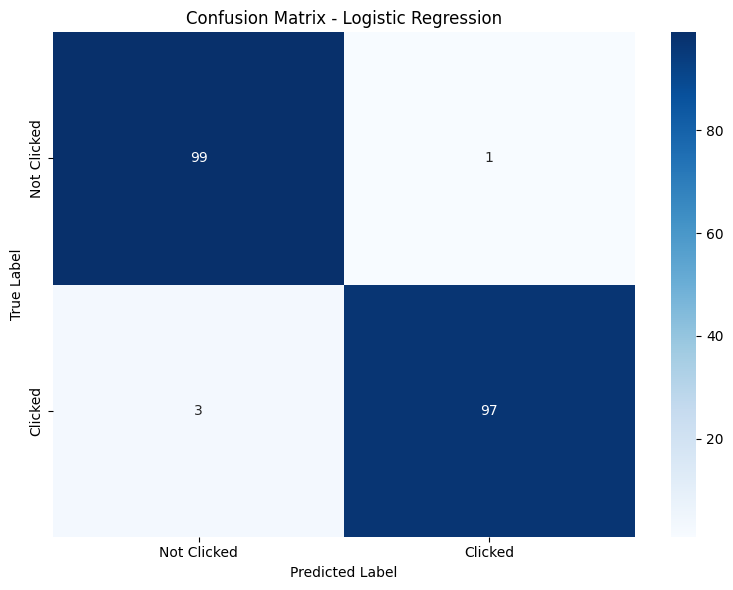


True Negatives: 99
False Positives: 1
False Negatives: 3
True Positives: 97


In [ ]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Not Clicked', 'Clicked'],
            yticklabels=['Not Clicked', 'Clicked'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")

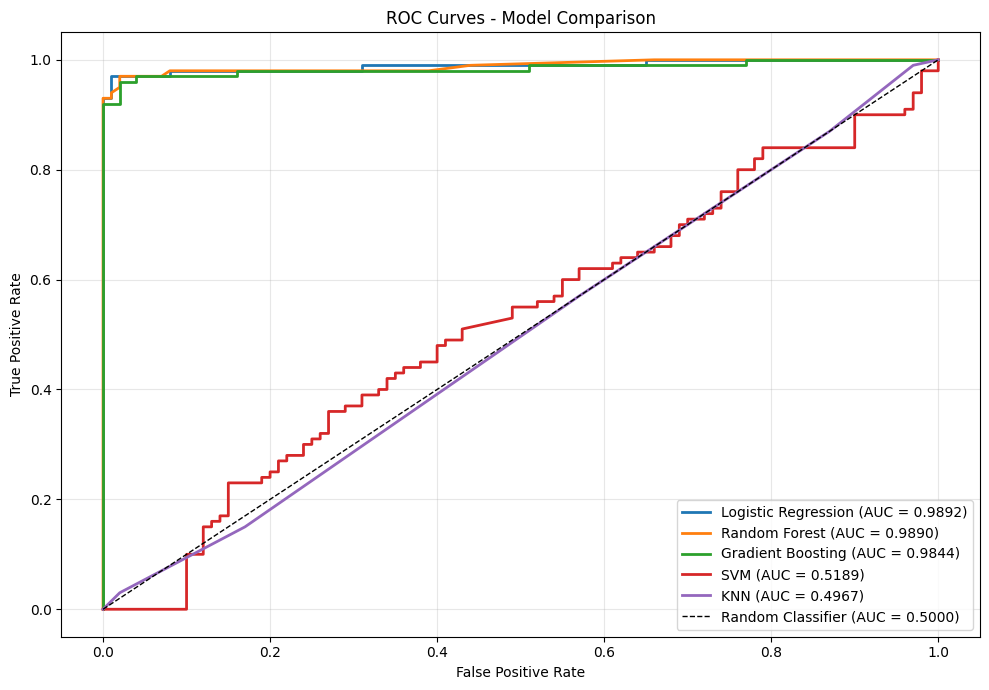

In [ ]:
# ROC curves for all models
plt.figure(figsize=(10, 7))

for model_name, model_obj in models.items():
    if hasattr(model_obj, 'predict_proba'):
        y_pred_proba = model_obj.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model_obj.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Step 14: Feature Importance Analysis

**Purpose:** Understand which features contribute most to predictions in tree-based models.

---

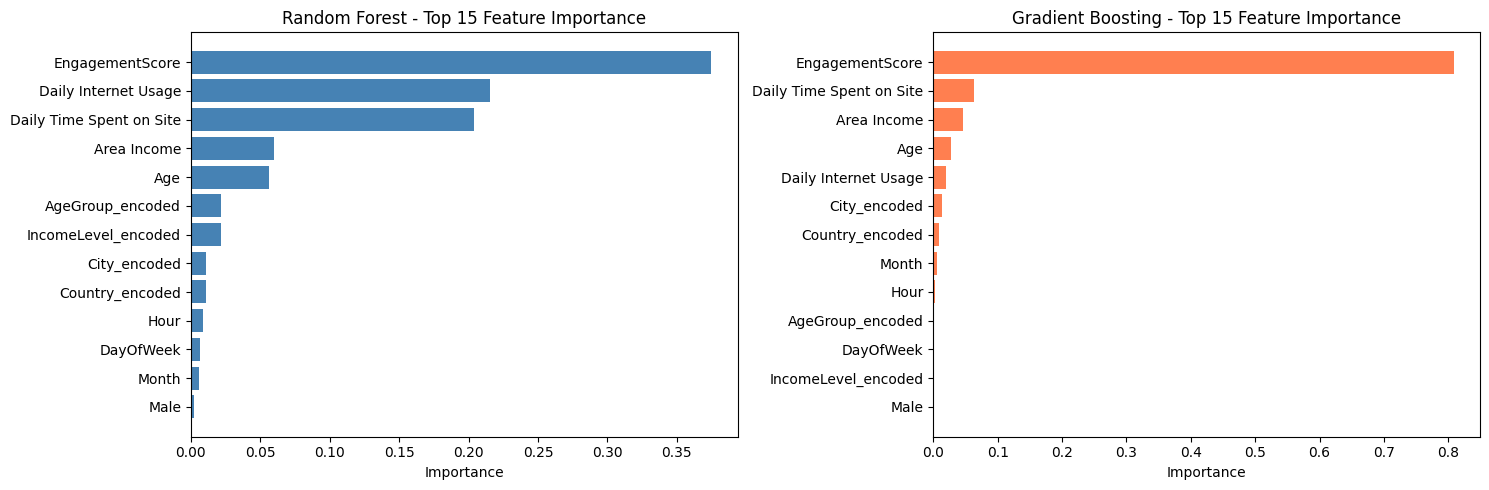


Random Forest - Top 10 Features:
                 Feature  Importance
         EngagementScore    0.374958
    Daily Internet Usage    0.215700
Daily Time Spent on Site    0.204180
             Area Income    0.060149
                     Age    0.056234
        AgeGroup_encoded    0.021800
     IncomeLevel_encoded    0.021696
            City_encoded    0.011147
         Country_encoded    0.011067
                    Hour    0.008688

Gradient Boosting - Top 10 Features:
                 Feature  Importance
         EngagementScore    0.808803
Daily Time Spent on Site    0.063137
             Area Income    0.046763
                     Age    0.027665
    Daily Internet Usage    0.019899
            City_encoded    0.013650
         Country_encoded    0.008232
                   Month    0.006296
                    Hour    0.002006
        AgeGroup_encoded    0.001677


In [ ]:
# Feature importance for Random Forest and Gradient Boosting
feature_names = X_train.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Random Forest Feature Importance
rf_importance = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False).head(15)

axes[0].barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='steelblue')
axes[0].set_title('Random Forest - Top 15 Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Gradient Boosting Feature Importance
gb_importance = gb_model.feature_importances_
gb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_importance
}).sort_values('Importance', ascending=False).head(15)

axes[1].barh(gb_importance_df['Feature'], gb_importance_df['Importance'], color='coral')
axes[1].set_title('Gradient Boosting - Top 15 Feature Importance')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nRandom Forest - Top 10 Features:")
print(rf_importance_df.head(10).to_string(index=False))
print("\nGradient Boosting - Top 10 Features:")
print(gb_importance_df.head(10).to_string(index=False))

---

## PROJECT COMPLETION SUMMARY

### Data Preprocessing Complete:
- Data quality checks (missing values, duplicates)
- Categorical encoding (Label Encoding for City, Country)
- Outlier handling (IQR Capping)
- Feature engineering (AgeGroup, IncomeLevel, EngagementScore)
- Feature reduction (Correlation analysis, PCA)
- Skewness analysis with log1p transformation
- StandardScaler normalization
- Preprocessing artifacts saved for production

### Model Training Complete:
- 5 models trained: Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN
- All models evaluated on test set (80-20 split, stratified)

### Performance Metrics:
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC score for each model
- Confusion matrix for best model
- Feature importance analysis

### Deliverables:
- ✓ Trained models (pickle files)
- ✓ Scaler and preprocessing metadata
- ✓ Model evaluation results
- ✓ Feature importance rankings

---

In [ ]:
# Save the best model for deployment
import pickle

with open(f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"[OK] Best model saved: best_model_{best_model_name.replace(' ', '_').lower()}.pkl")

# Save all models
with open('all_trained_models.pkl', 'wb') as f:
    pickle.dump(models, f)
print(f"[OK] All models saved: all_trained_models.pkl")

print("\n" + "="*70)
print("PROJECT SUCCESSFULLY COMPLETED!")
print("="*70)
print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {max(accuracies):.4f}")
print("\nFiles created:")
print("  - best_model_<name>.pkl (Best trained model)")
print("  - all_trained_models.pkl (All 5 models)")
print("  - scaler_standard.pkl (Feature scaling)")
print("  - label_encoder_city.pkl (Categorical encoding)")
print("  - preprocessing_metadata.json (Preprocessing info)")
print("="*70)

[OK] Best model saved: best_model_logistic_regression.pkl
[OK] All models saved: all_trained_models.pkl

PROJECT SUCCESSFULLY COMPLETED!
Best Model: Logistic Regression
Test Accuracy: 0.9800

Files created:
  - best_model_<name>.pkl (Best trained model)
  - all_trained_models.pkl (All 5 models)
  - scaler_standard.pkl (Feature scaling)
  - label_encoder_city.pkl (Categorical encoding)
  - preprocessing_metadata.json (Preprocessing info)
